# ELSA Depression Prediction
### MSc AI & Health — Group Assignment

**Goal:** Use Wave 6 features to predict whether a participant has depression at Wave 7.

**Target variable:** `hepsyde` — *Psychiatric problem: depression* (0 = not mentioned, 1 = mentioned)

**Models:** Random Forest + XGBoost (compared side by side)

## Cell 1 — Install & Import Libraries

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Cell 2 — Load the Data

In [2]:
w6 = pd.read_csv('ELSA_Dataset/ELSA_Clean/clean_wave_6_elsa_data_v2.csv')
w7 = pd.read_csv('ELSA_Dataset/ELSA_Clean/clean_wave_7_elsa_data.csv')

print(f'Wave 6: {w6.shape[0]:,} participants, {w6.shape[1]} columns')
print(f'Wave 7: {w7.shape[0]:,} participants, {w7.shape[1]} columns')

print('\nWave 6 columns:', list(w6.columns))
print('\nWave 7 columns:', list(w7.columns))

Wave 6: 10,601 participants, 39 columns
Wave 7: 9,666 participants, 39 columns

Wave 6 columns: ['idauniq', 'perid', 'DiSex', 'DiMar', 'HeAge', 'DiMaedu', 'MiLive', 'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc', 'Heiqa', 'Heiqb', 'Heiqc', 'Heiqd', 'Heiqe', 'hepsyde', 'hepsyan', 'hepsyem', 'hepsyps', 'hepsymo', 'hepsyma', 'PScedA', 'PScedB', 'PScedC', 'PScedD', 'PScedE', 'PScedF', 'PScedG', 'PScedH']

Wave 7 columns: ['idauniq', 'perid', 'DiSex', 'DiMar', 'HeAge', 'DiMaedu', 'MiLive', 'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5', 'Hehelf', 'Heill', 'Helim', 'HePain', 'HeSmk', 'HeActa', 'HeActb', 'HeActc', 'Heiqa', 'Heiqb', 'Heiqc', 'Heiqd', 'Heiqe', 'hepsyde', 'hepsyan', 'hepsyem', 'hepsyps', 'hepsymo', 'hepsyma', 'PScedA', 'PScedB', 'PScedC', 'PScedD', 'PScedE', 'PScedF', 'PScedG', 'PScedH']


## CES-D-8 Score Computation
Compute binary scored items and total score for both waves before any further processing.

In [3]:
# ── CES-D-8 Definitions ───────────────────────────────────────────────
# PScedD (Happy) and PScedF (Enjoyed life) are POSITIVE affect items — reverse scored
# All items encoded: 1 = Yes, 2 = No
# Normal items:  Yes(1) = symptom → binary 1
# Reverse items: Yes(1) = no symptom → binary 0

PSCED_COLS = ['PScedA','PScedB','PScedC','PScedD','PScedE','PScedF','PScedG','PScedH']
REVERSE_ITEMS = ['PScedD', 'PScedF']

ITEM_LABELS = {
    'PScedA': 'Depressed',
    'PScedB': 'Effortful',
    'PScedC': 'Restless sleep',
    'PScedD': 'Happy (R)',
    'PScedE': 'Lonely',
    'PScedF': 'Enjoyed life (R)',
    'PScedG': 'Sad',
    'PScedH': 'Could not get going',
}

def compute_cesd(df):
    """Add binary CES-D items and total score to a wave dataframe."""
    d = df.copy()
    for col in PSCED_COLS:
        d[col] = d[col].replace([-1, -8, -9], np.nan)
        bin_col = col + '_bin'
        if col in REVERSE_ITEMS:
            d[bin_col] = d[col].map({1: 0, 2: 1})
        else:
            d[bin_col] = d[col].map({1: 1, 2: 0})
    bin_cols = [c + '_bin' for c in PSCED_COLS]
    d['cesd_total'] = d[bin_cols].sum(axis=1, min_count=1)
    return d, bin_cols

w6, bin_cols = compute_cesd(w6)
w7, _        = compute_cesd(w7)

print(f'CES-D-8 scores computed.')
print(f'Wave 6 mean CES-D total: {w6["cesd_total"].mean():.2f}')
print(f'Wave 7 mean CES-D total: {w7["cesd_total"].mean():.2f}')


CES-D-8 scores computed.
Wave 6 mean CES-D total: 1.36
Wave 7 mean CES-D total: 1.36


## Cell 3 — Build the Target Variable (Wave 7 Depression)

`hepsyde` = 1 means the participant mentioned depression as a psychiatric problem at Wave 7.  
We treat this as our binary prediction target.

In [4]:
# ELSA uses negative values as missing/not applicable codes
MISSING_CODES = [-1, -2, -3, -4, -8, -9]

# Extract target from wave 7
w7_target = w7[['idauniq', 'hepsyde']].copy()
w7_target['hepsyde'] = w7_target['hepsyde'].replace(MISSING_CODES, np.nan)

# Keep only participants with a valid depression label
w7_target = w7_target.dropna(subset=['hepsyde'])
w7_target['depressed_w7'] = w7_target['hepsyde'].astype(int)

print(f'Wave 7 participants with valid depression label: {len(w7_target):,}')
print(f"\nClass balance:")
print(f"  Depressed (hepsyde=1): {w7_target['depressed_w7'].sum()} ({w7_target['depressed_w7'].mean()*100:.1f}%)")
print(f"  Not depressed (hepsyde=0): {(w7_target['depressed_w7']==0).sum()} ({(1-w7_target['depressed_w7'].mean())*100:.1f}%)")

Wave 7 participants with valid depression label: 1,011

Class balance:
  Depressed (hepsyde=1): 692 (68.4%)
  Not depressed (hepsyde=0): 319 (31.6%)


## Cell 4 — Select Features from Wave 6

We use Wave 6 data to predict Wave 7 outcomes — this is a **longitudinal prediction** setup.

Feature categories:
- **Sociodemographic:** sex, marital status, education
- **Social contact:** WhoSo1–5 (who participant socialises with)
- **Physical health:** self-rated health, illness, pain, smoking, activity
- **Prior mental health:** hepsyde, hepsyan etc. from Wave 6 (strongest predictors)

In [5]:
FEATURE_COLS = [
    # Sociodemographic
    'DiSex',     # Sex (1=male, 2=female)
    'DiMar',     # Marital status
    'DiMaedu',   # Education level

    # Social contact indicators
    'WhoSo1', 'WhoSo2', 'WhoSo3', 'WhoSo4', 'WhoSo5',

    # Physical health
    'Hehelf',    # Self-rated health (1=excellent, 5=poor)
    'Heill',     # Long-standing illness
    'Helim',     # Health limits daily activities
    'HePain',    # Pain
    'HeSmk',     # Smoking
    'HeActa',    # Vigorous physical activity
    'HeActb',    # Moderate physical activity
    'HeActc',    # Mild physical activity

    # Prior wave mental health (Wave 6)
    'hepsyde',   # Had depression at wave 6
    'hepsyan',   # Anxiety at wave 6
    'hepsyem',   # Emotional problems at wave 6
    'hepsyps',   # Positive mental health
    'hepsymo',   # Morale
    'hepsyma',   # Mastery/control
    # CES-D-8 binary items (reverse-scored where needed) + total score
    'PScedA_bin', 'PScedB_bin', 'PScedC_bin', 'PScedD_bin',
    'PScedE_bin', 'PScedF_bin', 'PScedG_bin', 'PScedH_bin',
    'cesd_total'
]

w6_features = w6[['idauniq'] + FEATURE_COLS].copy()

# Replace all ELSA missing codes with NaN
for col in FEATURE_COLS:
    w6_features[col] = w6_features[col].replace(MISSING_CODES, np.nan)

print(f'Wave 6 features extracted: {len(FEATURE_COLS)} features')
print(f'\nMissing data summary (% missing):')
missing_pct = (w6_features[FEATURE_COLS].isnull().sum() / len(w6_features) * 100).round(1)
print(missing_pct[missing_pct > 0].to_string())

Wave 6 features extracted: 31 features

Missing data summary (% missing):
DiMaedu        9.7
Hehelf         5.9
Heill          0.1
Helim         45.5
HePain         5.9
HeSmk         56.7
hepsyde       89.7
hepsyan       89.7
hepsyem       89.7
hepsyps       89.7
hepsymo       89.7
hepsyma       89.7
PScedA_bin     6.5
PScedB_bin     6.5
PScedC_bin     6.4
PScedD_bin     6.6
PScedE_bin     6.5
PScedF_bin     6.7
PScedG_bin     6.6
PScedH_bin     6.5
cesd_total     6.4


## Cell 5 — Merge Waves & Final Dataset

In [6]:
# Inner join: keep only participants present in both waves with a valid target
df = pd.merge(
    w6_features,
    w7_target[['idauniq', 'depressed_w7']],
    on='idauniq',
    how='inner'
)

print(f'Final dataset: {len(df):,} participants')
print(f'Depressed at Wave 7: {df["depressed_w7"].sum()} ({df["depressed_w7"].mean()*100:.1f}%)')
print(f'Not depressed: {(df["depressed_w7"]==0).sum()} ({(1-df["depressed_w7"].mean())*100:.1f}%)')

# Separate features and target
X = df[FEATURE_COLS]
y = df['depressed_w7']

print(f'\nFeature matrix shape: {X.shape}')

Final dataset: 929 participants
Depressed at Wave 7: 628 (67.6%)
Not depressed: 301 (32.4%)

Feature matrix shape: (929, 31)


## CES-D-8 Analysis
How Wave 6 CES-D scores relate to depression at Wave 7.

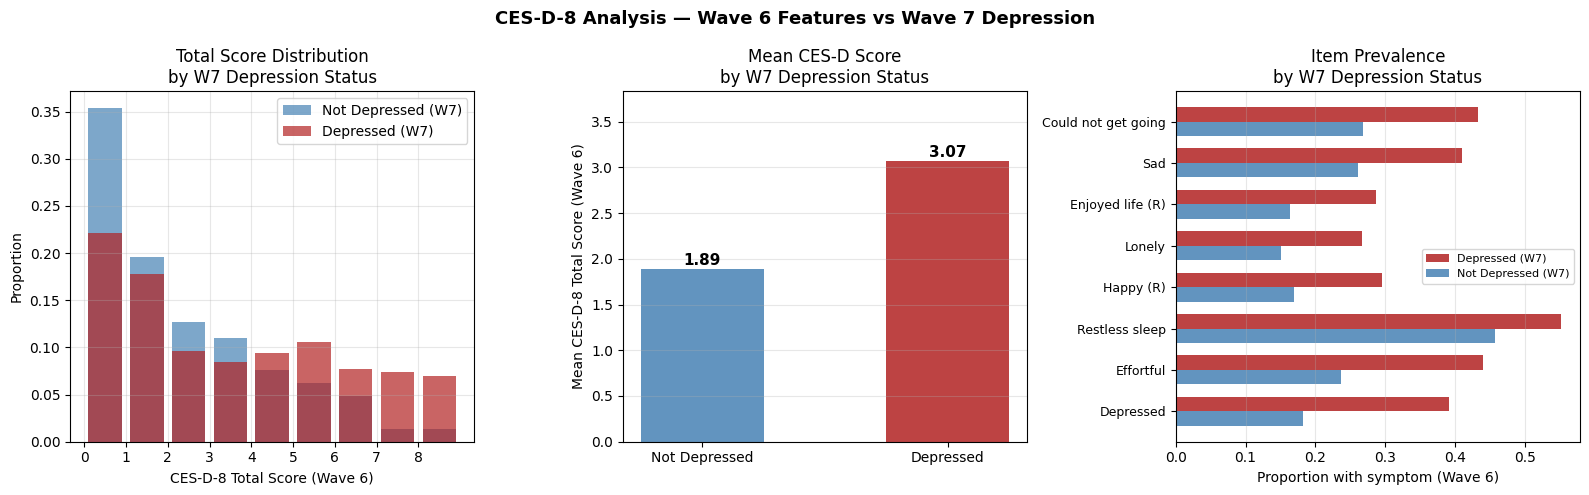

Saved: cesd_analysis.png


In [7]:
import matplotlib.patches as mpatches

# Use merged df (created in Cell 5) for analysis
dep   = df[df['depressed_w7'] == 1]['cesd_total']
nodep = df[df['depressed_w7'] == 0]['cesd_total']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('CES-D-8 Analysis — Wave 6 Features vs Wave 7 Depression', fontsize=13, fontweight='bold')

# Plot 1: Score distribution by depression status
axes[0].hist(nodep, bins=range(0,10), alpha=0.7, color='steelblue', label='Not Depressed (W7)', density=True, rwidth=0.8)
axes[0].hist(dep,   bins=range(0,10), alpha=0.7, color='firebrick', label='Depressed (W7)',     density=True, rwidth=0.8)
axes[0].set_xlabel('CES-D-8 Total Score (Wave 6)')
axes[0].set_ylabel('Proportion')
axes[0].set_title('Total Score Distribution\nby W7 Depression Status')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_xticks(range(0,9))

# Plot 2: Mean score per group
means = df.groupby('depressed_w7')['cesd_total'].mean()
bars = axes[1].bar(['Not Depressed', 'Depressed'], means.values,
                   color=['steelblue','firebrick'], alpha=0.85, width=0.5)
for bar, val in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Mean CES-D-8 Total Score (Wave 6)')
axes[1].set_title('Mean CES-D Score\nby W7 Depression Status')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].set_ylim(0, max(means.values)*1.25)

# Plot 3: Item-level symptom prevalence
item_rates_dep   = df[df['depressed_w7']==1][bin_cols].mean()
item_rates_nodep = df[df['depressed_w7']==0][bin_cols].mean()
short_labels = [ITEM_LABELS[c] for c in PSCED_COLS]
x = np.arange(len(PSCED_COLS)); bw = 0.35
axes[2].barh(x+bw/2, item_rates_dep.values,   bw, color='firebrick', alpha=0.85, label='Depressed (W7)')
axes[2].barh(x-bw/2, item_rates_nodep.values, bw, color='steelblue', alpha=0.85, label='Not Depressed (W7)')
axes[2].set_yticks(x); axes[2].set_yticklabels(short_labels, fontsize=9)
axes[2].set_xlabel('Proportion with symptom (Wave 6)')
axes[2].set_title('Item Prevalence\nby W7 Depression Status')
axes[2].legend(fontsize=8); axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cesd_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cesd_analysis.png')


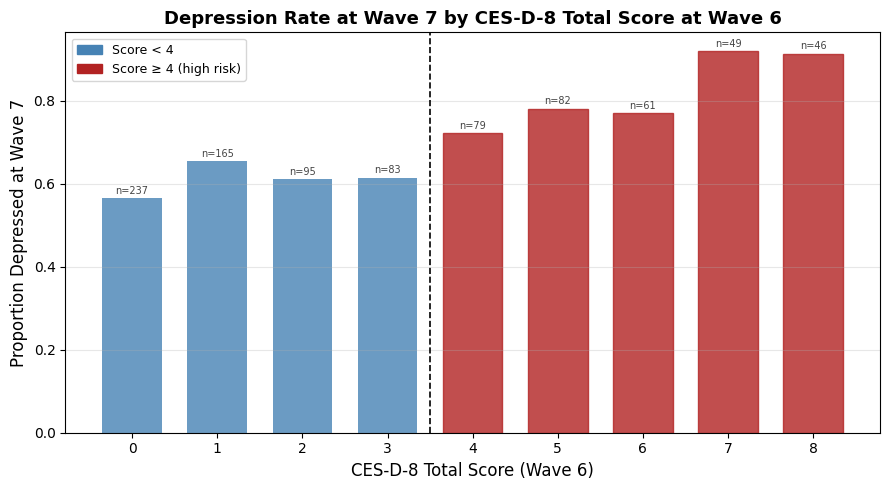

Saved: cesd_depression_rate.png


In [8]:
score_dep_rate = df.groupby('cesd_total')['depressed_w7'].agg(['mean','count']).reset_index()
score_dep_rate.columns = ['cesd_total','dep_rate','count']

fig2, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(score_dep_rate['cesd_total'], score_dep_rate['dep_rate'],
              color='steelblue', alpha=0.8, width=0.7)
for bar, score in zip(bars, score_dep_rate['cesd_total']):
    if score >= 4:
        bar.set_color('firebrick')
for bar, row in zip(bars, score_dep_rate.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'n={row.count}', ha='center', fontsize=7, color='#444')
ax.axvline(x=3.5, color='black', linestyle='--', linewidth=1.2)
ax.set_xlabel('CES-D-8 Total Score (Wave 6)', fontsize=12)
ax.set_ylabel('Proportion Depressed at Wave 7', fontsize=12)
ax.set_title('Depression Rate at Wave 7 by CES-D-8 Total Score at Wave 6', fontsize=13, fontweight='bold')
ax.set_xticks(range(0,9))
blue_p = mpatches.Patch(color='steelblue', label='Score < 4')
red_p  = mpatches.Patch(color='firebrick', label='Score ≥ 4 (high risk)')
ax.legend(handles=[blue_p, red_p], fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cesd_depression_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cesd_depression_rate.png')


In [9]:
summary_rows = []
for col, bc in zip(PSCED_COLS, bin_cols):
    r_dep   = df[df['depressed_w7']==1][bc].mean()
    r_nodep = df[df['depressed_w7']==0][bc].mean()
    summary_rows.append({
        'Item':               col,
        'Label':              ITEM_LABELS[col],
        'Not Depressed (W7)': f'{r_nodep:.1%}',
        'Depressed (W7)':     f'{r_dep:.1%}',
        'Difference':         f'{r_dep - r_nodep:+.1%}',
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f'\nMean CES-D total — Not Depressed: {nodep.mean():.2f}')
print(f'Mean CES-D total — Depressed:     {dep.mean():.2f}')
print(f'Difference:                       +{dep.mean()-nodep.mean():.2f}')
summary_df


  Item               Label Not Depressed (W7) Depressed (W7) Difference
PScedA           Depressed              18.2%          39.2%     +21.0%
PScedB           Effortful              23.7%          44.1%     +20.3%
PScedC      Restless sleep              45.7%          55.1%      +9.4%
PScedD           Happy (R)              16.9%          29.6%     +12.7%
PScedE              Lonely              15.1%          26.6%     +11.5%
PScedF    Enjoyed life (R)              16.3%          28.7%     +12.3%
PScedG                 Sad              26.1%          41.0%     +14.9%
PScedH Could not get going              26.8%          43.3%     +16.5%

Mean CES-D total — Not Depressed: 1.89
Mean CES-D total — Depressed:     3.07
Difference:                       +1.18


,Item,Label,Not Depressed (W7),Depressed (W7),Difference
0,PScedA,Depressed,18.2%,39.2%,+21.0%
1,PScedB,Effortful,23.7%,44.1%,+20.3%
2,PScedC,Restless sleep,45.7%,55.1%,+9.4%
3,PScedD,Happy (R),16.9%,29.6%,+12.7%
4,PScedE,Lonely,15.1%,26.6%,+11.5%
5,PScedF,Enjoyed life (R),16.3%,28.7%,+12.3%
6,PScedG,Sad,26.1%,41.0%,+14.9%
7,PScedH,Could not get going,26.8%,43.3%,+16.5%


## Cell 6 — Train / Test Split

In [10]:
# Stratified split preserves class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,
    stratify=y
)

print(f'Training set: {len(X_train):,} participants ({y_train.mean()*100:.1f}% depressed)')
print(f'Test set:     {len(X_test):,} participants ({y_test.mean()*100:.1f}% depressed)')

Training set: 743 participants (67.6% depressed)
Test set:     186 participants (67.7% depressed)


## Cell 7 — Train Random Forest

Key settings:
- `n_estimators=300` — 300 trees in the forest
- `class_weight='balanced'` — automatically handles class imbalance
- `SimpleImputer` — fills missing values with the median before training

In [11]:
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)

print('Random Forest trained.')
print(f'ROC-AUC on test set: {rf_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['Not Depressed', 'Depressed']))

Random Forest trained.
ROC-AUC on test set: 0.769

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.60      0.65      0.62        60
    Depressed       0.83      0.79      0.81       126

     accuracy                           0.75       186
    macro avg       0.71      0.72      0.72       186
 weighted avg       0.75      0.75      0.75       186



## Cell 8 — Train XGBoost

XGBoost is a **gradient boosting** model — instead of building trees independently (like Random Forest), it builds each tree to correct the errors of the previous one. Often more accurate, but slightly harder to tune.

In [12]:
# Calculate scale_pos_weight to handle class imbalance (equivalent to class_weight='balanced')
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'Class imbalance ratio (scale_pos_weight): {scale:.2f}')

xgb_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=scale,   # handles class imbalance
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print('\nXGBoost trained.')
print(f'ROC-AUC on test set: {xgb_auc:.3f}')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=['Not Depressed', 'Depressed']))

Class imbalance ratio (scale_pos_weight): 0.48

XGBoost trained.
ROC-AUC on test set: 0.729

Classification Report:
               precision    recall  f1-score   support

Not Depressed       0.56      0.55      0.55        60
    Depressed       0.79      0.79      0.79       126

     accuracy                           0.72       186
    macro avg       0.67      0.67      0.67       186
 weighted avg       0.71      0.72      0.71       186



## Cell 9 — Cross Validation (More Robust Evaluation)

A single train/test split can be lucky or unlucky. 5-fold cross-validation gives a more reliable estimate of true model performance.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv  = cross_val_score(rf_pipeline,  X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
xgb_cv = cross_val_score(xgb_pipeline, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('5-Fold Cross-Validation AUC:')
print(f'  Random Forest: {rf_cv.mean():.3f}  (+/- {rf_cv.std():.3f})')
print(f'  XGBoost:       {xgb_cv.mean():.3f}  (+/- {xgb_cv.std():.3f})')

5-Fold Cross-Validation AUC:
  Random Forest: 0.728  (+/- 0.043)
  XGBoost:       0.695  (+/- 0.048)


## Cell 10 — Plot Results: Confusion Matrices & ROC Curves

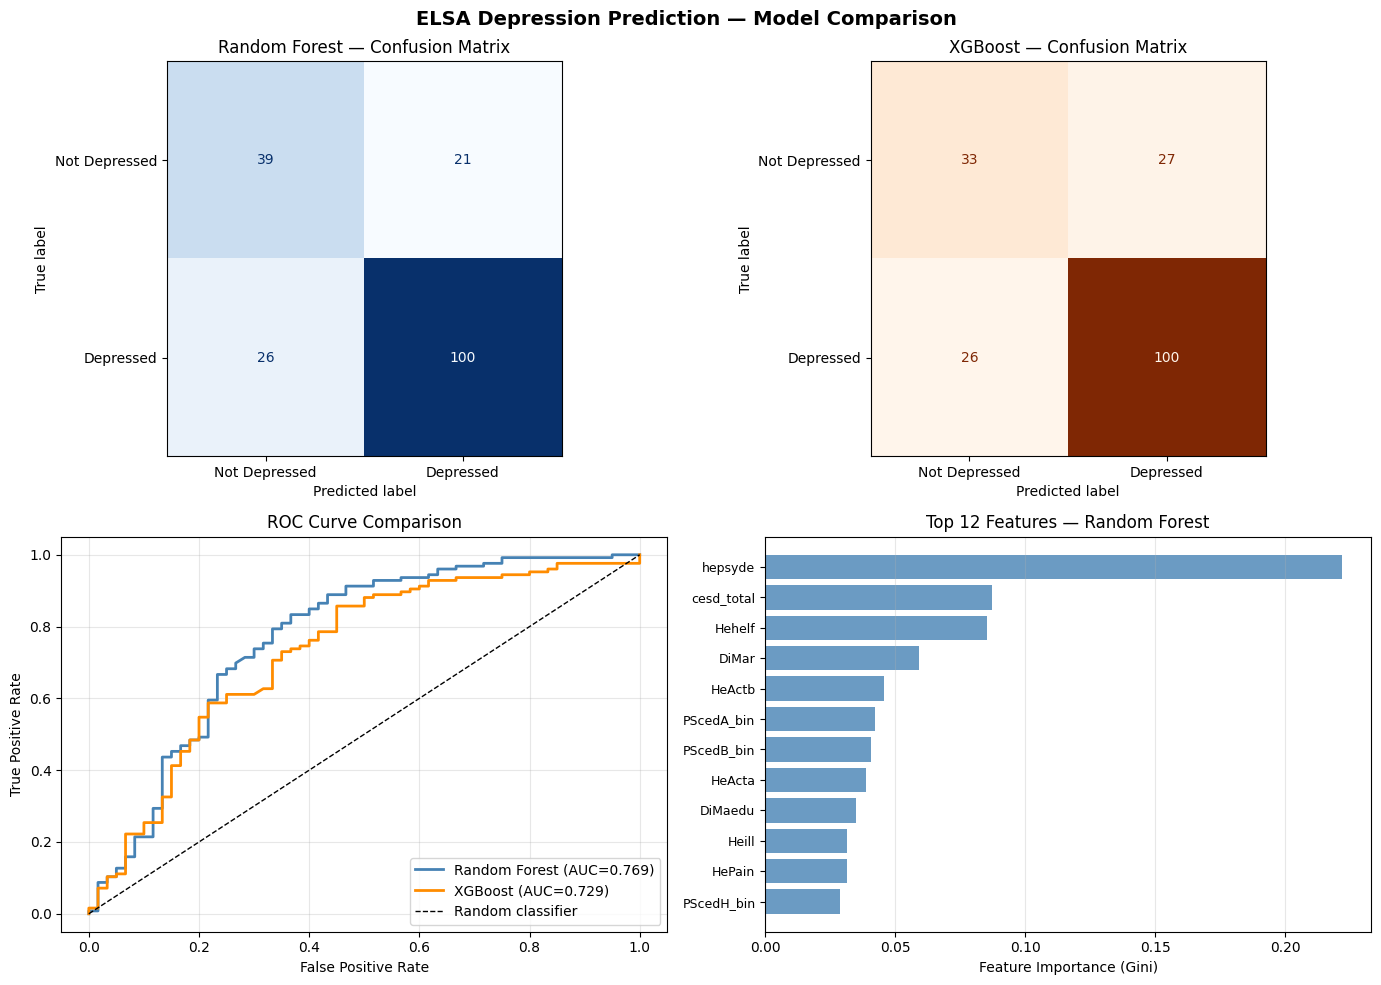

Plot saved as elsa_results.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ELSA Depression Prediction — Model Comparison', fontsize=14, fontweight='bold')

# --- Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, rf_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 0], colorbar=False, cmap='Blues')
axes[0, 0].set_title('Random Forest — Confusion Matrix')

# --- Confusion Matrix: XGBoost ---
ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_pred),
    display_labels=['Not Depressed', 'Depressed']
).plot(ax=axes[0, 1], colorbar=False, cmap='Oranges')
axes[0, 1].set_title('XGBoost — Confusion Matrix')

# --- ROC Curve: Both models ---
for prob, label, color, auc in [
    (rf_prob,  'Random Forest', 'steelblue', rf_auc),
    (xgb_prob, 'XGBoost',       'darkorange', xgb_auc),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[1, 0].plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})', color=color)

axes[1, 0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Feature Importance: Random Forest ---
rf_model = rf_pipeline.named_steps['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:12]

axes[1, 1].barh(
    range(len(indices)),
    importances[indices][::-1],
    color='steelblue', alpha=0.8
)
axes[1, 1].set_yticks(range(len(indices)))
axes[1, 1].set_yticklabels([FEATURE_COLS[i] for i in indices][::-1], fontsize=9)
axes[1, 1].set_xlabel('Feature Importance (Gini)')
axes[1, 1].set_title('Top 12 Features — Random Forest')
axes[1, 1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('elsa_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as elsa_results.png')

## Cell 11 — Feature Importance: XGBoost

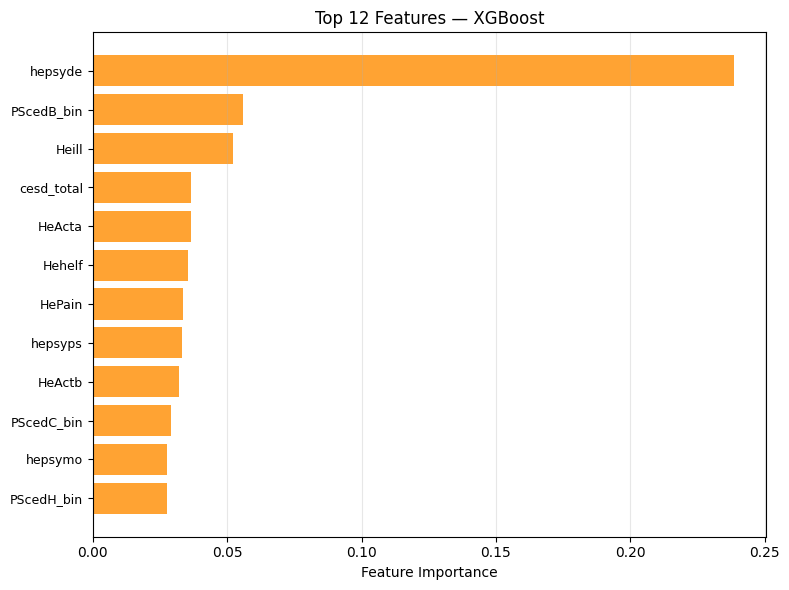

In [15]:
xgb_model = xgb_pipeline.named_steps['model']
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1][:12]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(
    range(len(xgb_indices)),
    xgb_importances[xgb_indices][::-1],
    color='darkorange', alpha=0.8
)
ax.set_yticks(range(len(xgb_indices)))
ax.set_yticklabels([FEATURE_COLS[i] for i in xgb_indices][::-1], fontsize=9)
ax.set_xlabel('Feature Importance')
ax.set_title('Top 12 Features — XGBoost')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('elsa_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 12 — Summary Table

In [16]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy':  [accuracy_score(y_test, rf_pred),  accuracy_score(y_test, xgb_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, xgb_pred)],
    'Recall':    [recall_score(y_test, rf_pred),    recall_score(y_test, xgb_pred)],
    'F1 Score':  [f1_score(y_test, rf_pred),        f1_score(y_test, xgb_pred)],
    'ROC-AUC':   [rf_auc,                           xgb_auc],
    'CV AUC (mean)': [rf_cv.mean(),                 xgb_cv.mean()],
}).round(3)

results = results.set_index('Model')
print(results.to_string())
results

               Accuracy  Precision  Recall  F1 Score  ROC-AUC  CV AUC (mean)
Model                                                                       
Random Forest     0.747      0.826   0.794     0.810    0.769          0.728
XGBoost           0.715      0.787   0.794     0.791    0.729          0.695


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,CV AUC (mean)
Model,,,,,,
Random Forest,0.747,0.826,0.794,0.810,0.769,0.728
XGBoost,0.715,0.787,0.794,0.791,0.729,0.695
